In [5]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.collections import LineCollection
from pathlib import Path

In [18]:
#config

ANNEE   = 2024
GP      = "Bahrain"   # Nom du Grand Prix tel que dans les données FastF1
SESSION = "Q"          # Q=Qualifs, R=Race, FP1/FP2/FP3
PILOTE1 = "VER"        # Code 3 lettres
PILOTE2 = "LEC"

CACHE_DIR = Path("./fastf1_cache")
CACHE_DIR.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE_DIR))

# Thème sombre façon broadcast F1
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a1a",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ccc",
    "xtick.color":      "#888",
    "ytick.color":      "#888",
    "grid.color":       "#2a2a2a",
    "grid.linewidth":   0.6,
    "text.color":       "white",
    "font.family":      "monospace",
})

In [19]:
# chargement session
print(f"Chargement {GP} {ANNEE} — {SESSION}...")
session = fastf1.get_session(ANNEE, GP, SESSION)
session.load(telemetry=True, laps=True)

# Meilleur tour de chaque pilote
lap1 = session.laps.pick_driver(PILOTE1).pick_fastest()
lap2 = session.laps.pick_driver(PILOTE2).pick_fastest()

tel1 = lap1.get_car_data().add_distance()
tel2 = lap2.get_car_data().add_distance()

# Couleurs officielles des équipes
color1 = fastf1.plotting.get_team_color(lap1["Team"], session=session)
color2 = fastf1.plotting.get_team_color(lap2["Team"], session=session)

delta_t1 = lap1["LapTime"].total_seconds()
delta_t2 = lap2["LapTime"].total_seconds()
delta_str = f"+{abs(delta_t1 - delta_t2):.3f}s"
faster = PILOTE1 if delta_t1 < delta_t2 else PILOTE2

Chargement Bahrain 2024 — Q...


core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

Graphe sauvegardé : /workspaces/f1_data_and_weather/outputf1_bahrain_2024_VER_vs_LEC.png


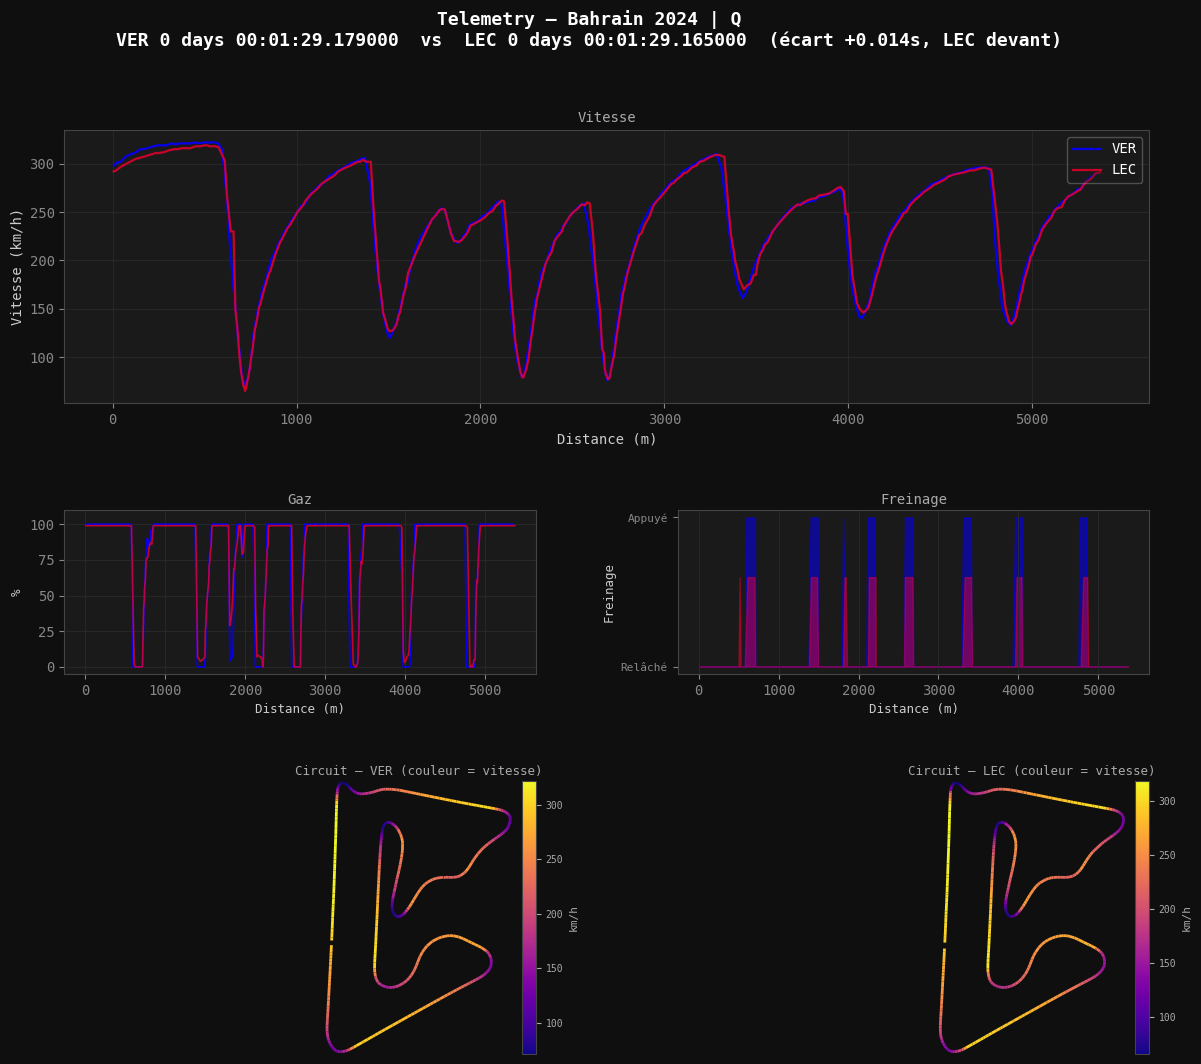

In [20]:
# plot

from operator import pos


fig = plt.figure(figsize=(14, 12))
fig.suptitle(
    f"Telemetry — {GP} {ANNEE} | {SESSION}\n"
    f"{PILOTE1} {lap1['LapTime']}  vs  {PILOTE2} {lap2['LapTime']}  (écart {delta_str}, {faster} devant)",
    fontsize=13, y=0.98, color="white", fontweight="bold"
)

# Grille : 3 lignes — vitesse, throttle/frein, mini-map
gs = fig.add_gridspec(3, 2, height_ratios=[2, 1.2, 2], hspace=0.45, wspace=0.3)

ax_spd  = fig.add_subplot(gs[0, :])   # Vitesse (pleine largeur)
ax_thr  = fig.add_subplot(gs[1, 0])   # Throttle
ax_brk  = fig.add_subplot(gs[1, 1])   # Frein
ax_map1 = fig.add_subplot(gs[2, 0])   # Mini-map pilote 1
ax_map2 = fig.add_subplot(gs[2, 1])   # Mini-map pilote 2


# ── 1. Trace de vitesse ───────────────────────────────────────────────────────

ax_spd.plot(tel1["Distance"], tel1["Speed"], color=color1, lw=1.6, label=PILOTE1)
ax_spd.plot(tel2["Distance"], tel2["Speed"], color=color2, lw=1.6, label=PILOTE2, alpha=0.85)

ax_spd.set_ylabel("Vitesse (km/h)", fontsize=10)
ax_spd.set_xlabel("Distance (m)", fontsize=10)
ax_spd.legend(loc="upper right", fontsize=10, framealpha=0.3)
ax_spd.yaxis.set_major_locator(mticker.MultipleLocator(50))
ax_spd.grid(True, axis="both")
ax_spd.set_title("Vitesse", fontsize=10, color="#aaa", pad=6)


# ── 2. Throttle ──────────────────────────────────────────────────────────────

ax_thr.plot(tel1["Distance"], tel1["Throttle"], color=color1, lw=1.2, label=PILOTE1)
ax_thr.plot(tel2["Distance"], tel2["Throttle"], color=color2, lw=1.2, label=PILOTE2, alpha=0.8)
ax_thr.set_ylabel("%", fontsize=9)
ax_thr.set_xlabel("Distance (m)", fontsize=9)
ax_thr.set_title("Gaz", fontsize=10, color="#aaa", pad=4)
ax_thr.set_ylim(-5, 110)
ax_thr.grid(True)


# ── 3. Frein ─────────────────────────────────────────────────────────────────

# Frein est booléen (0/1) dans FastF1 → on affiche comme zones colorées
ax_brk.fill_between(tel1["Distance"], tel1["Brake"].astype(int),
                    alpha=0.55, color=color1, label=PILOTE1)
ax_brk.fill_between(tel2["Distance"], tel2["Brake"].astype(int) * 0.6,
                    alpha=0.45, color=color2, label=PILOTE2)
ax_brk.set_ylabel("Freinage", fontsize=9)
ax_brk.set_xlabel("Distance (m)", fontsize=9)
ax_brk.set_title("Freinage", fontsize=10, color="#aaa", pad=4)
ax_brk.set_yticks([0, 1])
ax_brk.set_yticklabels(["Relâché", "Appuyé"], fontsize=8)
ax_brk.grid(True, axis="x")


# ── 4. Mini-maps colorées par vitesse ────────────────────────────────────────

def draw_speed_map(ax, tel, driver_name, color_min="#1a1a6e", color_max="#ff4500"):
    """Trace le circuit coloré par vitesse (dégradé bleu → orange)."""
    pos = lap1.get_pos_data() if driver_name == PILOTE1 else lap2.get_pos_data()

    # Aligner la position sur la télémétrie par SessionTime
    tel_time = tel["SessionTime"].dt.total_seconds().values
    pos_time = pos["SessionTime"].dt.total_seconds().values
    speed_interp = np.interp(pos_time, tel_time, tel["Speed"].values)

    x = pos["X"].values
    y = pos["Y"].values

    # Normaliser la vitesse pour la colormap
    vmin, vmax = speed_interp.min(), speed_interp.max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.plasma  # Jaune-violet très lisible

    # Créer les segments de ligne
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
    lc.set_array(speed_interp[:-1])
    ax.add_collection(lc)

    ax.set_xlim(x.min() - 100, x.max() + 100)
    ax.set_ylim(y.min() - 100, y.max() + 100)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"Circuit — {driver_name} (couleur = vitesse)", fontsize=9, color="#aaa", pad=4)

    cbar = fig.colorbar(lc, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("km/h", fontsize=8, color="#aaa")
    cbar.ax.yaxis.set_tick_params(color="#aaa", labelsize=7)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#aaa")

draw_speed_map(ax_map1, tel1, PILOTE1)
draw_speed_map(ax_map2, tel2, PILOTE2)


# ── Export ───────────────────────────────────────────────────────────────────

output_path = f"/workspaces/f1_data_and_weather/outputf1_{GP.lower()}_{ANNEE}_{PILOTE1}_vs_{PILOTE2}.png"
plt.savefig(output_path, dpi=180, bbox_inches="tight", facecolor="#0f0f0f")
print(f"Graphe sauvegardé : {output_path}")
plt.show()